In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as st

path = "archive/games.json"

In [3]:

# wilson score calculation
def wilson_score(pos, neg, total, z=1.96):
    pos = pos.astype(float)
    neg = neg.astype(float)
    total = total.astype(float)
    phat = pos / total.replace(0, np.nan)
    return (phat + z**2 / (2 * total) - z * np.sqrt((phat * (1 - phat) + z**2 / (4 * total)) / total)) / (1 + z**2 / total)

In [4]:
# Load the original dataset
df_original = pd.read_json(path).T

In [5]:
# Magic numbers
well_received_threshold = 0.75
review_count_threshold = 20
max_age_restriction = 100
common_tags_threshold = 5000

# Columns to convert to numeric, filling missing values with 0 and converting to appropriate types
cols_to_convert = [
    'price', 'required_age', 'dlc_count', 'achievements', 
    'positive', 'negative', 'average_playtime_forever', 
    'median_playtime_forever', 'discount', 'peak_ccu'
]

#  I did my best to make sure to filter out games with explicit content, but it's possible some slipped through.
#  I also filtered out games with less than 50 reviews to do my
#  best to avoid games that are less likely to be family-friendly.
banned_terms = [ "nudity", "sexual", "mature", "adult", "nsfw", "hentai", "sexual content"]



In [6]:
# checking the number of games before filtering
print("before filtering:", len(df_original))

# Drop columns that are not needed for the analysis
df = df_original.drop(columns=["developers", "publishers", "screenshots", "movies", "user_score", "score_rank", "about_the_gadetailed_descriptionme", "" ])

# Convert specified columns to numeric, filling missing values with 0 and converting to appropriate types
for col in cols_to_convert:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate total reviews and Wilson score, and determine if the game is well received based on the Wilson score threshold
df["total_reviews"] =df["positive"] + df["negative"]
df["wilson_score"] = wilson_score(df["positive"], df["negative"], df["total_reviews"])

df["well_received"] = df["wilson_score"] >= well_received_threshold

# Filter out games with banned genres or tags, as well as those that are age restricted or have too few reviews
banned_genres_df = ~df["genres"].apply(
    lambda genres: any(
        any(term in genre.lower() for term in banned_terms)
        for genre in genres
    ) if isinstance(genres, list) else False
)
banned_tags_df = ~df["tags"].apply(
    lambda tags: any(
        any(term in tag.lower() for term in banned_terms)
        for tag in tags.keys()
    ) if isinstance(tags, dict) else False
)

# Filter based on age restriction and review count, i origianlly filtered by age restriction of 18 but i changed it to 100 since i found the tags filters are pretty much good enough
age_retriction = df["required_age"] < max_age_restriction
review_restriction = df["total_reviews"] > review_count_threshold

# Apply all filters to the DataFrame
df = df[banned_tags_df & age_retriction & review_restriction & banned_genres_df]
# Check the number of games after filtering and the remaining columns
print("after filtering:", len(df))
print(df.columns.tolist())

before filtering: 122610
after filtering: 40194
['name', 'release_date', 'required_age', 'price', 'dlc_count', 'detailed_description', 'about_the_game', 'short_description', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'achievements', 'recommendations', 'notes', 'supported_languages', 'full_audio_languages', 'packages', 'categories', 'genres', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'tags', 'total_reviews', 'wilson_score', 'well_received']


In [7]:
# Convert platform availability to numeric
df["windows"] = df["windows"].astype(int)
df["mac"] = df["mac"].astype(int)
df["linux"] = df["linux"].astype(int)

# Calculate the number of supported languages and the midpoint of the estimated owners range
df["num_languages"] = df["supported_languages"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
df["estimated_owners_mid"] = df["estimated_owners"].apply(
    lambda x: np.mean([int(v.replace(',','')) for v in x.split(' - ')])
)

# One-hot encode genres, tags, and categories
category_df = pd.get_dummies(df["categories"].explode()).groupby(level=0).sum()
category_df = category_df.add_prefix("category_")

genre_df = pd.get_dummies(df["genres"].explode()).groupby(level=0).sum()
genre_df = genre_df.add_prefix("genre_")
tag_df = pd.json_normalize(df["tags"]).fillna(0)

# Filter out tags that are not common enough to reduce dimensionality
tag_counts = tag_df.sum()
common_tags = tag_counts[tag_counts > common_tags_threshold].index
tag_df = tag_df[common_tags]

# Prefix tag columns to avoid name clashes
tag_df = tag_df.add_prefix("tag_")

# Join the one-hot encoded genres, tags, and categories back to the main DataFrame
joined_df = df.join(genre_df)
joined_df = joined_df.join(tag_df)
joined_df = joined_df.join(category_df)

# Calculate the number of genres and tags for each game to use as additional features
joined_df["genre_count"] = joined_df["genres"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)
joined_df["tag_count"] = joined_df["tags"].apply(
    lambda x: len(x) if isinstance(x, dict) else 0
)

# Define the feature set and target variable for modeling
base_features = [
             "genre_count",
            "tag_count",
            "price",
            "dlc_count",
            "recommendations",
            "achievements",
            "required_age",
            "windows",
            "mac",
            "linux",
            "num_languages",
            "average_playtime_forever",
            "median_playtime_forever",
            "average_playtime_2weeks",
            "peak_ccu",
            "estimated_owners_mid"    
]

# Combine base features with one-hot encoded genres, tags, and categories to create the final feature set
X = joined_df[base_features + list(genre_df.columns) + list(tag_df.columns) + list(category_df.columns)]
Y = joined_df["well_received"]
X = X.fillna(0)


In [8]:

# Split the data into training, validation, and test sets (60% train, 20% validation, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_test, Y_test, test_size=0.5, random_state=42)


# Scale the features using StandardScaler
scaler = StandardScaler()

# Train a logistic regression model and evaluate its performance on the test set
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# picks best c using the validation
best_C = None
best_val_score = -1
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    m = LogisticRegression(max_iter=10000, C=C)
    m.fit(X_train_scaled, Y_train)
    val_score = roc_auc_score(Y_val, m.predict_proba(X_val_scaled)[:, 1])
    print(f"C={C}: val AUC = {val_score:.4f}")
    if val_score > best_val_score:
        best_val_score = val_score
        best_C = C

print(f"\nBest C: {best_C}")

X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=10000, C=best_C)
model.fit(X_train_scaled, Y_train)
Y_pred = model.predict(X_test_scaled)

# Evaluate the model's performance using accuracy and classification report
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)

# Calculate ROC AUC score
Y_prob = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(Y_test, Y_prob)

# print the results
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("well_received_threshold: ", well_received_threshold)
print(classification_report(Y_test, Y_pred))
print(f"ROC AUC Score: {roc_auc:.4f}")


C=0.01: val AUC = 0.7146
C=0.1: val AUC = 0.7165
C=1: val AUC = 0.7177
C=10: val AUC = 0.7181
C=100: val AUC = 0.7189
C=1000: val AUC = 0.7176

Best C: 100
Train: (24116, 507), Val: (8039, 507), Test: (8039, 507)
well_received_threshold:  0.75
              precision    recall  f1-score   support

       False       0.68      0.77      0.72      4447
        True       0.65      0.55      0.60      3592

    accuracy                           0.67      8039
   macro avg       0.67      0.66      0.66      8039
weighted avg       0.67      0.67      0.66      8039

ROC AUC Score: 0.7253


In [9]:
# Take the first tag from each question as the "primary" tag
df["primary_tag"] = df["tags"].apply(
    lambda x: list(x.keys())[0] if isinstance(x, dict) and len(x) > 0 else None
)

# Drop rows with no tags
df_tagged = df.dropna(subset=["primary_tag"])

# Keep only common tags so the table isn't huge
top_tags = df_tagged["primary_tag"].value_counts().head(20).index
df_tagged = df_tagged[df_tagged["primary_tag"].isin(top_tags)]

# Contingency table
table = pd.crosstab(df_tagged["primary_tag"], df_tagged["well_received"])

# Chi-square test
chi2, p, dof, expected = st.chi2_contingency(table)

# Effect size with Cramer's V
n = len(df_tagged)
min_dim = min(table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramer's V: {cramers_v:.4f}")
print(f"Min expected frequency: {expected.min():.2f}")

Chi-square: 943.9241
p-value: 0.0000
Degrees of freedom: 19
Cramer's V: 0.1793
Min expected frequency: 89.23


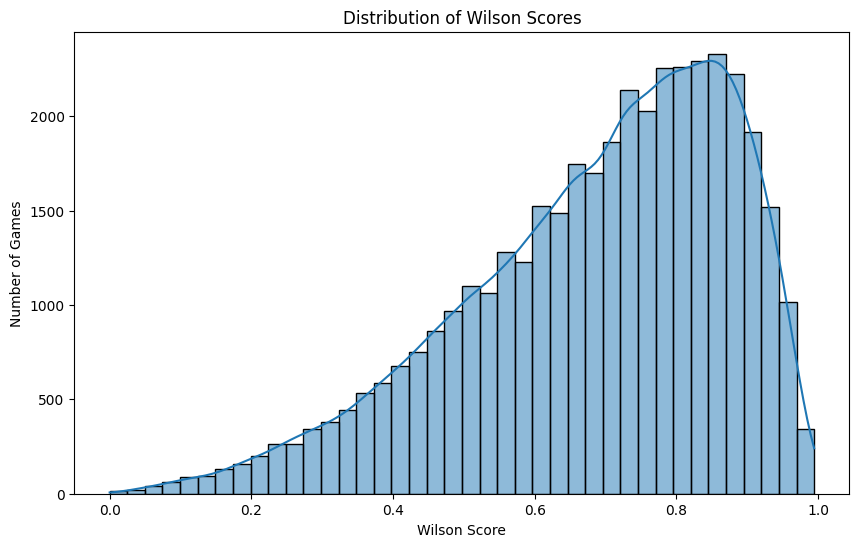

In [10]:
# Visualize the distribution of Wilson scores
plt.figure(figsize=(10, 6))
sns.histplot(joined_df["wilson_score"], bins=40, kde=True)
plt.title("Distribution of Wilson Scores")
plt.xlabel("Wilson Score")
plt.ylabel("Number of Games")
plt.show()

Text(0.5, 0, 'Pearson Correlation')

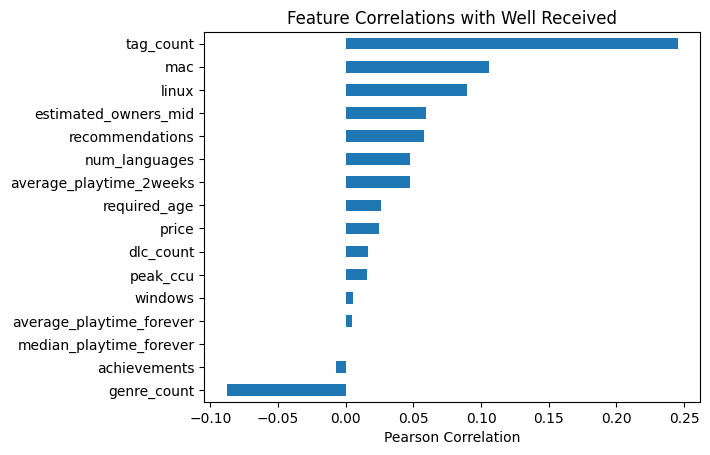

In [11]:
numeric_cols = ["price", "dlc_count", "achievements", "recommendations",
                "average_playtime_forever", "median_playtime_forever", 
                "peak_ccu", "estimated_owners_mid", "num_languages"]

# Visualize the correlation of numeric features with the target variable
correlations = joined_df[base_features + ["well_received"]].corr()["well_received"].drop("well_received").sort_values()
correlations.plot(kind="barh")
plt.title("Feature Correlations with Well Received")
plt.xlabel("Pearson Correlation")

<Axes: xlabel='well_received', ylabel='count'>

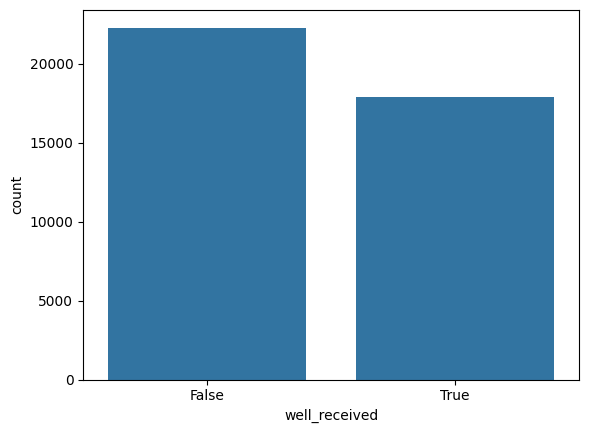

In [12]:
# Visualize the distribution of well received vs not well received games
sns.countplot(x="well_received", data=df)

Text(0.5, 0, 'Number of Games')

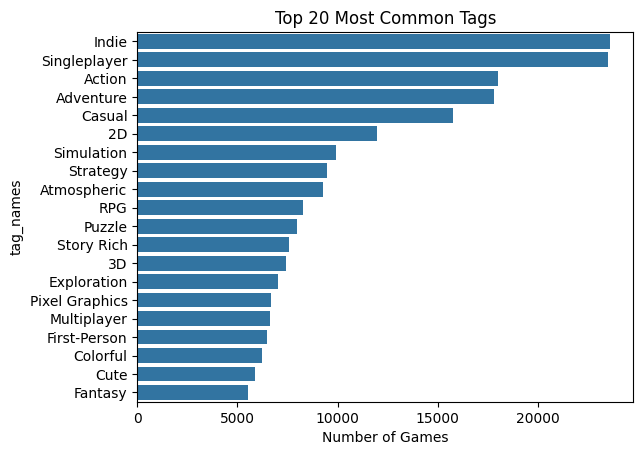

In [13]:
# Extract tag names from the tags dictionary and create a new column with the list of tag names
df["tag_names"] = df["tags"].apply(
    lambda x: list(x.keys()) if isinstance(x, dict) else []
)
# Explode the tag names to count the frequency of each tag and visualize the top 20 most common tags
tag_df = df.explode("tag_names")
top_tags = tag_df["tag_names"].value_counts().head(20)

# Visualize the top 20 most common tags
sns.barplot(
    x=top_tags.values,
    y=top_tags.index
)
plt.title("Top 20 Most Common Tags")
plt.xlabel("Number of Games")

Text(0.5, 0, 'Proportion Well Received')

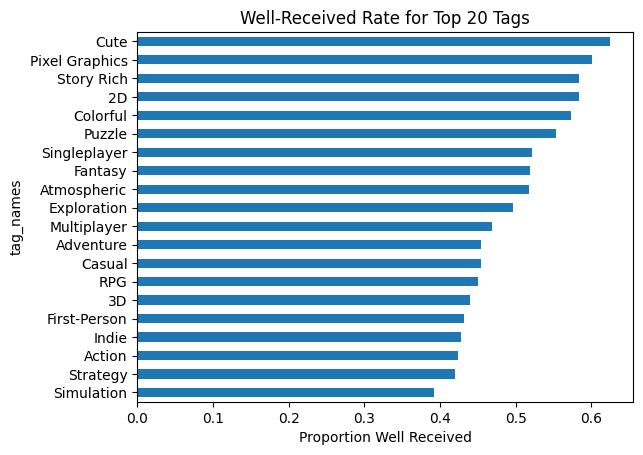

In [14]:
# Calculate the proportion of well received games for each tag and visualize the top 20 tags by well received rate,
# I didnt end up using this in the final model but i thought it would be interesting to see which tags are more likely to be well received
tag_success = (
    tag_df.groupby("tag_names")["well_received"]
    .mean()
)
top_tag_success = tag_success.loc[
    tag_df["tag_names"].value_counts().head(20).index
]
top_tag_success.sort_values().plot(kind="barh")
plt.title("Well-Received Rate for Top 20 Tags")
plt.xlabel("Proportion Well Received")

In [15]:
# diplay the numeric variables, took a screenshot of this
pd.options.display.float_format = '{:.2f}'.format
df.describe().T

,count,mean,std,min,25%,50%,75%,max
required_age,40194.00,0.31,2.23,0.00,0.00,0.00,0.00,18.00
price,40194.00,5.30,9.85,0.00,0.99,2.99,6.99,299.90
dlc_count,40194.00,1.12,24.81,0.00,0.00,0.00,1.00,3703.00
windows,40194.00,1.00,0.01,0.00,1.00,1.00,1.00,1.00
mac,40194.00,0.26,0.44,0.00,0.00,0.00,1.00,1.00
linux,40194.00,0.17,0.38,0.00,0.00,0.00,0.00,1.00
achievements,40194.00,33.68,231.13,0.00,0.00,13.00,30.00,9821.00
positive,40194.00,2694.50,46819.88,0.00,30.00,77.00,329.00,7642084.00
negative,40194.00,432.18,9017.30,0.00,8.00,21.00,81.00,1173003.00
average_playtime_forever,40194.00,493.00,17482.66,0.00,0.00,9.00,233.00,3429544.00


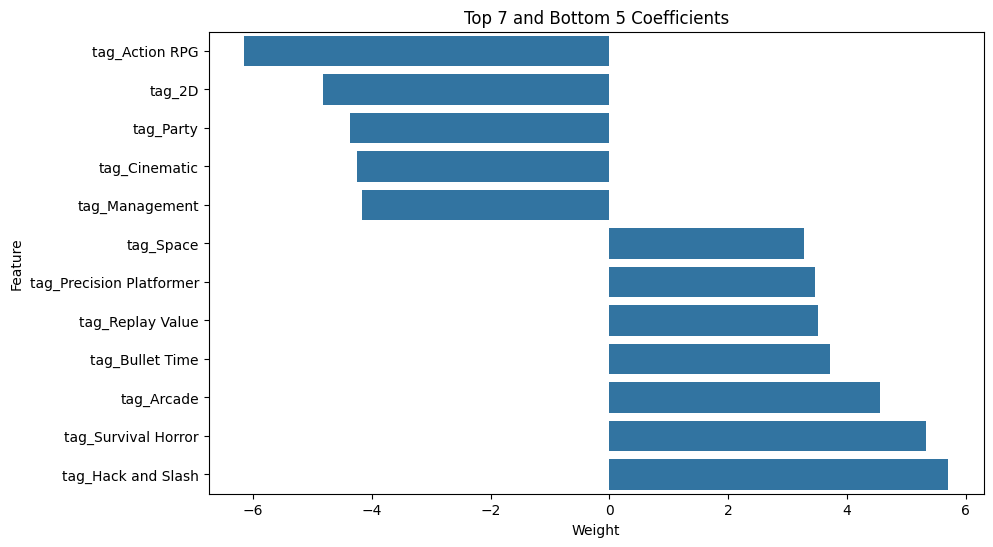

In [16]:
# Create the weights dataframe
importance = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
})

# Get the 7 strongest positive and 5 strongest negative
top_5 = importance.nlargest(7, 'Weight')
bottom_5 = importance.nsmallest(5, 'Weight')
top_and_bottom = pd.concat([top_5, bottom_5]).sort_values("Weight")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_and_bottom, x='Weight', y='Feature')
plt.title("Top 7 and Bottom 5 Coefficients")
plt.show()